# Analiza najbolje ocenjenih albumov (AlbumOfTheYear)

Podatki o 500+ najbolje ocenjenih albumih vseh časov, pridobljeni s strani [AlbumOfTheYear](https://www.albumoftheyear.org/ratings/6-highest-rated/all/1). Za vsak album imamo izvajalca, naslov, leto izida, žanre, kritiško oceno (0-100) in število recenzij, na podlagi katerih je bila ocena izračunana.

## 1. Nalaganje in priprava podatkov

Podatke naložimo enkrat na začetku in tu tudi izvedemo vse pretvorbe tipov (ocena, leto, žanri, desetletje), da so v vseh nadaljnjih celicah že pripravljeni za uporabo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('podatki/albumi.csv')

# pretvorba v številske tipe (v CSV-ju so ti stolpci shranjeni kot besedilo)
df['ocena'] = pd.to_numeric(df['ocena'], errors='coerce')
df['st_recenzij'] = pd.to_numeric(df['st_recenzij'], errors='coerce')
df['leto'] = pd.to_numeric(df['leto'], errors='coerce')

# odstranimo vrstice brez ocene ali leta - brez njiju vrstica ni uporabna
pred = len(df)
df = df.dropna(subset=['ocena', 'leto']).copy()
df['leto'] = df['leto'].astype(int)
print(f'Odstranjenih vrstic zaradi manjkajočih podatkov: {pred - len(df)}')

# žanre razbijemo v seznam za kasnejšo analizo posameznih žanrov
df['zanri_seznam'] = df['zanri'].fillna('').apply(
    lambda s: [z.strip() for z in s.split(',') if z.strip()]
)

df['desetletje'] = (df['leto'] // 10) * 10

print(f'Skupaj albumov: {len(df)}')
df.head(10)

Odstranjenih vrstic zaradi manjkajočih podatkov: 0
Skupaj albumov: 500


,izvajalec,naslov,leto,zanri,ocena,st_recenzij,zanri_seznam,desetletje
0,Kendrick Lamar,To Pimp a Butterfly,2015,"Conscious Hip Hop, Jazz Rap, West Coast Hip Ho...",95,47,"[Conscious Hip Hop, Jazz Rap, West Coast Hip H...",2010
1,The Beatles,Revolver,1966,"Pop Rock, Psychedelic Pop Psychedelic Rock, Ex...",100,9,"[Pop Rock, Psychedelic Pop Psychedelic Rock, E...",1960
2,Prince,"Sign ""☮︎"" the Times",1987,"Contemporary R&B Synth Funk, Pop Rock, Minneap...",99,9,"[Contemporary R&B Synth Funk, Pop Rock, Minnea...",1980
3,The Beatles,Abbey Road,1969,"Pop Rock Progressive Pop, Psychedelic Pop, Art...",100,8,"[Pop Rock Progressive Pop, Psychedelic Pop, Ar...",1960
4,Nick Cave and the Bad Seeds,Ghosteen,2019,"Singer-Songwriter Spoken Word, New Age, Ambient",93,37,"[Singer-Songwriter Spoken Word, New Age, Ambient]",2010
5,The Beatles,Rubber Soul,1965,"Pop Rock Folk Rock, Psychedelic Pop, Folk Pop,...",100,8,"[Pop Rock Folk Rock, Psychedelic Pop, Folk Pop...",1960
6,Kendrick Lamar,DAMN.,2017,"Conscious Hip Hop, West Coast Hip Hop Pop Rap,...",93,44,"[Conscious Hip Hop, West Coast Hip Hop Pop Rap...",2010
7,Fiona Apple,Fetch the Bolt Cutters,2020,"Art Pop, Singer-Songwriter, Progressive Pop Pi...",93,35,"[Art Pop, Singer-Songwriter, Progressive Pop P...",2020
8,Eno,Another Green World,1975,"Art Rock, Ambient Electronic, Art Pop",99,8,"[Art Rock, Ambient Electronic, Art Pop]",1970
9,Public Enemy,It Takes a Nation of Millions to Hold Us Back,1988,"Hardcore Hip Hop, East Coast Hip Hop, Consciou...",99,8,"[Hardcore Hip Hop, East Coast Hip Hop, Conscio...",1980


## 2. Porazdelitev ocen in top 10 albumov

Top 10 najbolje ocenjenih albumov:


,izvajalec,naslov,leto,ocena,st_recenzij
31,Metallica,Master of Puppets,1986,100,6
30,The Smiths,The Queen Is Dead,1986,100,6
75,Elvis Presley,Elvis Presley,1956,100,5
16,Paul Simon,Graceland,1986,100,7
32,Bob Dylan,Blood on the Tracks,1975,100,6
33,Miles Davis,Kind of Blue,1959,100,6
34,Leonard Cohen,Songs of Leonard Cohen,1967,100,6
35,Patti Smith,Horses,1975,100,6
38,Television,Marquee Moon,1977,100,6
74,Big Star,3rd,1978,100,5


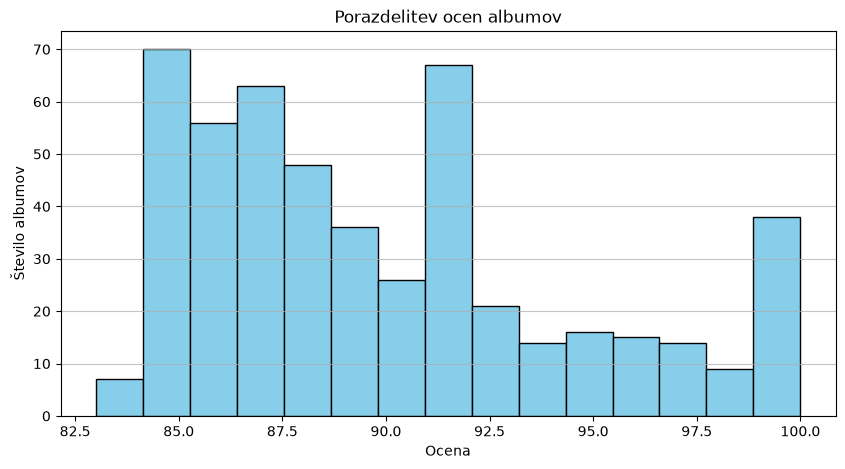

In [2]:
print('Top 10 najbolje ocenjenih albumov:')
display(df.sort_values(by='ocena', ascending=False).head(10)
        [['izvajalec', 'naslov', 'leto', 'ocena', 'st_recenzij']])

plt.figure(figsize=(10, 5))
plt.hist(df['ocena'], bins=15, color='skyblue', edgecolor='black')
plt.title('Porazdelitev ocen albumov')
plt.xlabel('Ocena')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Ocene so, pričakovano, zgoščene v zgornjem delu lestvice (saj gre za najbolje ocenjene albume vseh časov) - zanimivo je pogledati, kako strmo pada repozicija proti nižjim ocenam.

## 3. Izvajalci z največ albumi na lestvici

In [3]:
print('Izvajalci z največ albumi na seznamu:')
display(df['izvajalec'].value_counts().head(10))

# povprečna ocena po izvajalcih (samo tisti z vsaj 2 albumoma na lestvici)
top_izvajalci = df.groupby('izvajalec').filter(lambda x: len(x) >= 2)
povprecne_ocene = top_izvajalci.groupby('izvajalec')['ocena'].mean().sort_values(ascending=False)
print('\nIzvajalci z najvišjim povprečjem (vsaj 2 albuma):')
display(povprecne_ocene.head(10))

Izvajalci z največ albumi na seznamu:


izvajalec
The Beatles          8
David Bowie          6
Bob Dylan            6
Kendrick Lamar       5
Bruce Springsteen    5
Sufjan Stevens       4
Little Simz          4
Tom Waits            4
Mitski               4
St. Vincent          4
Name: count, dtype: int64


Izvajalci z najvišjim povprečjem (vsaj 2 albuma):


izvajalec
Stevie Wonder      99.500000
Pixies             99.500000
Grateful Dead      99.000000
Led Zeppelin       98.333333
Miles Davis        98.000000
Michael Jackson    98.000000
The Beatles        97.125000
Nick Drake         97.000000
Pink Floyd         96.666667
Talking Heads      96.500000
Name: ocena, dtype: float64

## 4. Albumi po desetletjih

Število top albumov po desetletjih:


desetletje
1950      2
1960     23
1970     64
1980     34
1990     60
2000     68
2010    114
2020    135
Name: count, dtype: int64

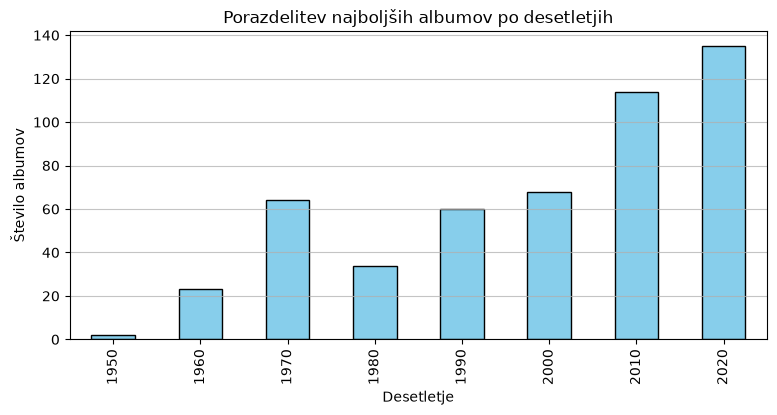

In [4]:
po_desetletju = df['desetletje'].value_counts().sort_index()
print('Število top albumov po desetletjih:')
display(po_desetletju)

plt.figure(figsize=(9, 4))
po_desetletju.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porazdelitev najboljših albumov po desetletjih')
plt.xlabel('Desetletje')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 5. Najpogostejši žanri

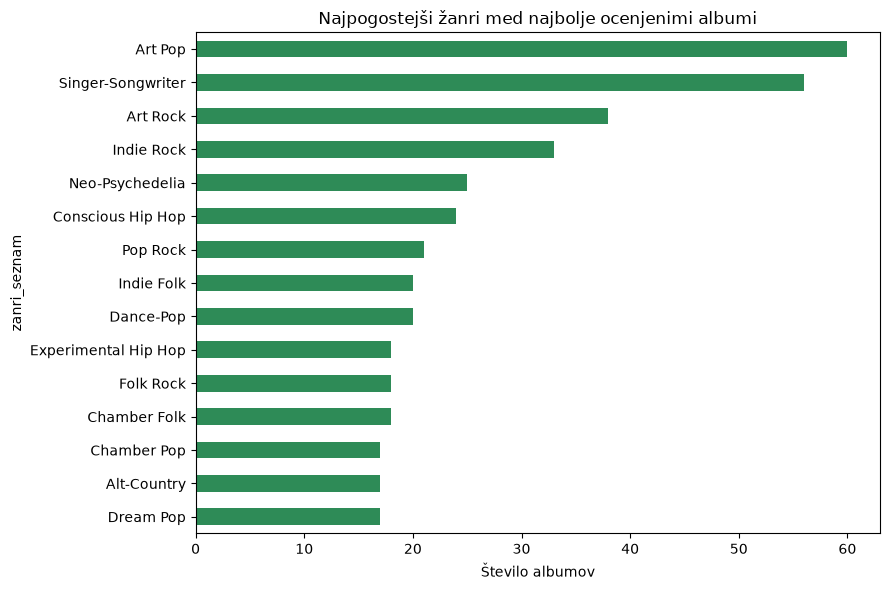

In [5]:
vsi_zanri = df.explode('zanri_seznam')['zanri_seznam']
vsi_zanri = vsi_zanri[vsi_zanri != '']
top_zanri = vsi_zanri.value_counts().head(15)

plt.figure(figsize=(9, 6))
top_zanri.plot(kind='barh', color='seagreen')
plt.xlabel('Število albumov')
plt.title('Najpogostejši žanri med najbolje ocenjenimi albumi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Razmerje med oceno in številom recenzij

Ali imajo bolj "priljubljeni" albumi (več recenzij) tudi višjo oceno?

Korelacija med oceno in številom recenzij: -0.607


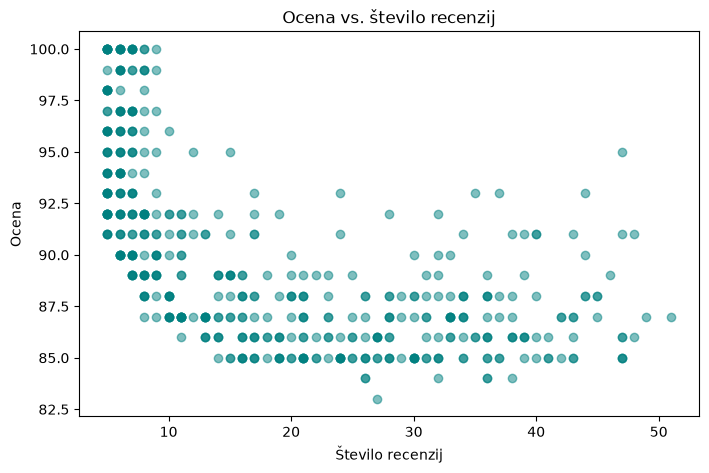

In [6]:
korelacija = df['ocena'].corr(df['st_recenzij'])
print(f'Korelacija med oceno in številom recenzij: {korelacija:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(df['st_recenzij'], df['ocena'], alpha=0.5, color='teal')
plt.xlabel('Število recenzij')
plt.ylabel('Ocena')
plt.title('Ocena vs. število recenzij')
plt.show()

## 7. Povzetek ugotovitev

*(Dopolni s konkretnimi ugotovitvami, ko poženeš zgornje celice na pravih podatkih - npr. katera desetletja/žanri prevladujejo, ali je ocena povezana s priljubljenostjo, kateri izvajalci izstopajo.)*